# 🟡 L07 — Optional Extensions
**⏱ Self-paced, ~45–60 minutes if you do all four sections. Dip in and out — each section stands alone.**

> *Pure self-study material. Skipping this will not affect any later lesson.*

Four sections:

1. **NumPy-from-scratch neural network** — forward + backward pass without any framework
2. **Weight initialisation** — why how you initialise matters (Xavier, He)
3. **Optimizer comparison** — SGD vs Adam vs AdamW vs RMSprop
4. **Batch normalisation** — what it does and when to use it

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# (Removed the old one-CPU-thread cap — it made CPU-only machines much slower.)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 5)
torch.manual_seed(42); np.random.seed(42)

# Standard setup (same data as in-class notebooks)
df = pd.read_csv("data/northstar_sessions.csv")
y_all = df["completed"].values
X_all = df.drop(columns=["session_id", "completed"]).values
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)
print("✅ Setup complete.")

✅ Setup complete.


# 1. NumPy-from-Scratch Neural Network

**Why bother?** All week `loss.backward()` has been a magic incantation. Doing it once by hand — like long division before you trust the calculator — removes the magic for good.

Train a tiny MLP using NO framework. Just NumPy arrays, manual forward pass, manual backward pass via the chain rule. The point: SEE what PyTorch's autograd is doing for you.

> 🧭 **Plain-English map of the backward pass** (for the maths comments in the next cell): the gradient flows *backwards* through the same steps the prediction flowed forwards — **how wrong was the prediction → how much did the output layer contribute → how much did the hidden layer contribute → how much did each weight contribute**. Each `d...` variable in the code is one link in that chain. You don't need to verify the calculus; just watch the blame being passed backwards, layer by layer.


In [2]:
# A 2-layer MLP from scratch
# Architecture: input → hidden(8, ReLU) → output(1, sigmoid)

def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def relu(x):    return np.maximum(0, x)
def relu_deriv(x): return (x > 0).astype(float)

n_features = X_tr_s.shape[1]
hidden = 8
rng = np.random.default_rng(42)

# Initialise weights (small random values)
W1 = rng.normal(0, 0.1, size=(n_features, hidden))
b1 = np.zeros(hidden)
W2 = rng.normal(0, 0.1, size=(hidden, 1))
b2 = np.zeros(1)

lr = 0.05
losses_np = []

for epoch in range(150):
    # FORWARD PASS
    z1 = X_tr_s @ W1 + b1            # (N, hidden)
    a1 = relu(z1)                     # apply ReLU
    z2 = a1 @ W2 + b2                # (N, 1)
    p = sigmoid(z2).flatten()         # (N,)

    # LOSS: binary cross-entropy
    p_clip = np.clip(p, 1e-7, 1 - 1e-7)
    loss = -np.mean(y_tr * np.log(p_clip) + (1 - y_tr) * np.log(1 - p_clip))
    losses_np.append(loss)

    # BACKWARD PASS (chain rule, by hand)
    N = len(y_tr)
    dp = (p - y_tr).reshape(-1, 1) / N     # ∂loss/∂p (and after sigmoid: ∂loss/∂z2)
    dW2 = a1.T @ dp
    db2 = dp.sum(axis=0)
    da1 = dp @ W2.T
    dz1 = da1 * relu_deriv(z1)
    dW1 = X_tr_s.T @ dz1
    db1 = dz1.sum(axis=0)

    # GRADIENT DESCENT STEP
    W1 -= lr * dW1; b1 -= lr * db1
    W2 -= lr * dW2; b2 -= lr * db2

# Evaluate
z1 = X_te_s @ W1 + b1; a1 = relu(z1)
z2 = a1 @ W2 + b2; p_test = sigmoid(z2).flatten()
auc_np = roc_auc_score(y_te, p_test)
print(f"NumPy-from-scratch MLP final loss: {losses_np[-1]:.4f}")
print(f"Test AUC: {auc_np:.3f}")
print()
print("Notice how much code was needed for the backward pass.")
print("PyTorch's `loss.backward()` does all of that in one line.")

NumPy-from-scratch MLP final loss: 0.6693
Test AUC: 0.704

Notice how much code was needed for the backward pass.
PyTorch's `loss.backward()` does all of that in one line.


# 2. Weight Initialisation

**Why care?** Training starts from *random* weights — and where you start affects whether gradient descent finds its way down at all. A bad starting point can silently cripple a network before the first step. Think of it like dropping hikers onto a mountain: drop them all on the exact same flat ledge and they'll all walk the same path.

If all weights start at 0, no learning happens (all neurons compute the same thing → identical gradients → no differentiation). Modern initialisations: **Xavier** (sigmoid/tanh) and **He** (ReLU).

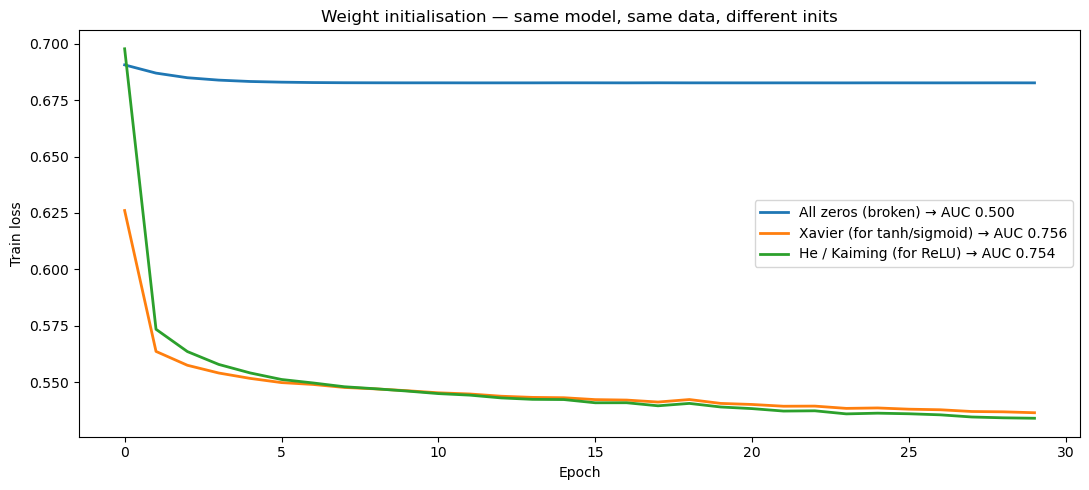

All-zeros init never learns — all neurons output the same thing.
Xavier and He inits work well; He is preferred for ReLU networks.


In [3]:
# Compare three init strategies: train the SAME architecture on the SAME data,
# changing ONLY how the starting weights are drawn.
def train_with_init(init_func, n_epochs=30, label=""):
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(n_features, 32), nn.ReLU(),
        nn.Linear(32, 32), nn.ReLU(),
        nn.Linear(32, 1),
    )
    # Overwrite the default starting weights with the strategy we're testing.
    for m in model.modules():
        if isinstance(m, nn.Linear):
            init_func(m.weight)
            nn.init.zeros_(m.bias)

    X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_te_t = torch.tensor(X_te_s, dtype=torch.float32)

    crit = nn.BCEWithLogitsLoss()
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)
    losses_local = []
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        for X_b, y_b in loader:
            opt.zero_grad()
            l = crit(model(X_b).squeeze(-1), y_b)
            l.backward(); opt.step()
            epoch_loss += l.item()
        losses_local.append(epoch_loss / len(loader))

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_te_t).squeeze(-1)).numpy()
    return losses_local, roc_auc_score(y_te, probs)


# Three init strategies
results = []
for init_func, name in [
    (lambda w: nn.init.zeros_(w),                    "All zeros (broken)"),
    (lambda w: nn.init.xavier_uniform_(w),           "Xavier (for tanh/sigmoid)"),
    (lambda w: nn.init.kaiming_uniform_(w, nonlinearity="relu"), "He / Kaiming (for ReLU)"),
]:
    losses_local, auc = train_with_init(init_func)
    results.append((name, losses_local, auc))

fig, ax = plt.subplots(figsize=(11, 5))
for name, losses_local, auc in results:
    ax.plot(losses_local, label=f"{name} → AUC {auc:.3f}", linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Train loss")
ax.set_title("Weight initialisation — same model, same data, different inits")
ax.legend()
plt.tight_layout(); plt.show()
print("All-zeros init never learns — all neurons output the same thing.")
print("Xavier and He inits work well; He is preferred for ReLU networks.")

# 3. Optimizer Comparison

**Why care?** The optimiser is the *rule* for turning gradients into weight updates — and different rules reach a good answer at very different speeds. In class we used Adam on faith; here we race it against SGD, SGD-with-momentum, AdamW and RMSprop on the same model and data, so you can see why Adam is the default. Same training loop everywhere — only the `optim.___` line changes.

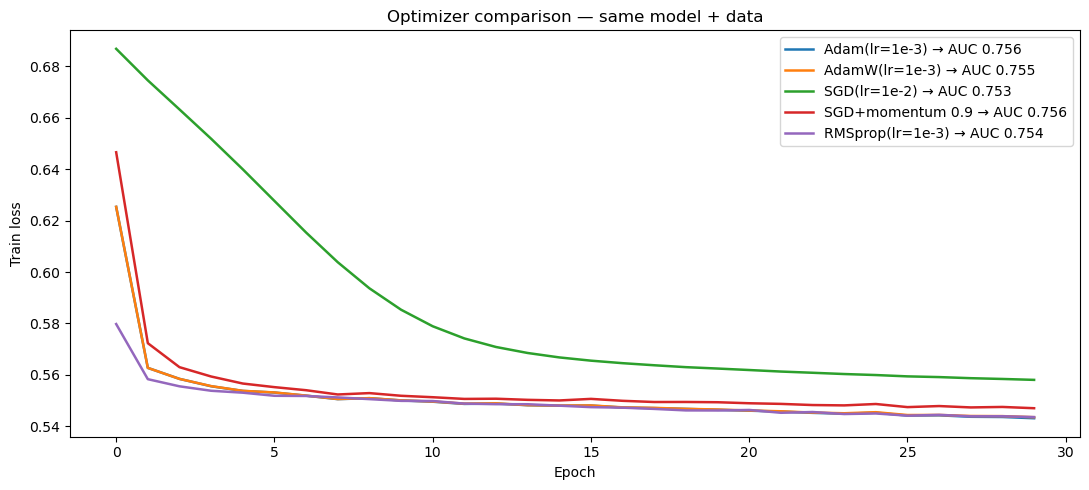

Adam / AdamW typically converge fastest with no tuning.
SGD-momentum can match or beat Adam with proper lr tuning, but needs more care.
RMSprop sits between — used to be popular before Adam.


In [4]:
# Helper: train a fresh copy of the same model with a given optimiser, return its
# per-epoch train loss + final test AUC — so the ONLY difference between runs is the optimiser.
def train_with_optimiser(optimiser_class, opt_kwargs, n_epochs=30):
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(n_features, 32), nn.ReLU(),
        nn.Linear(32, 32), nn.ReLU(),
        nn.Linear(32, 1),
    )
    crit = nn.BCEWithLogitsLoss()
    opt = optimiser_class(model.parameters(), **opt_kwargs)

    X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_te_t = torch.tensor(X_te_s, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)
    losses_local = []
    for epoch in range(n_epochs):
        model.train()
        epoch_l = 0
        for X_b, y_b in loader:
            opt.zero_grad()
            l = crit(model(X_b).squeeze(-1), y_b)
            l.backward(); opt.step()
            epoch_l += l.item()
        losses_local.append(epoch_l / len(loader))
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_te_t).squeeze(-1)).numpy()
    return losses_local, roc_auc_score(y_te, probs)


configs = [
    ("Adam(lr=1e-3)",     optim.Adam,    {"lr": 1e-3}),
    ("AdamW(lr=1e-3)",    optim.AdamW,   {"lr": 1e-3, "weight_decay": 0.01}),
    ("SGD(lr=1e-2)",      optim.SGD,     {"lr": 1e-2}),
    ("SGD+momentum 0.9",  optim.SGD,     {"lr": 1e-2, "momentum": 0.9}),
    ("RMSprop(lr=1e-3)",  optim.RMSprop, {"lr": 1e-3}),
]

fig, ax = plt.subplots(figsize=(11, 5))
for name, opt_cls, kw in configs:
    losses_local, auc = train_with_optimiser(opt_cls, kw)
    ax.plot(losses_local, label=f"{name} → AUC {auc:.3f}", linewidth=1.8)
ax.set_xlabel("Epoch"); ax.set_ylabel("Train loss")
ax.set_title("Optimizer comparison — same model + data")
ax.legend()
plt.tight_layout(); plt.show()
print("Adam / AdamW typically converge fastest with no tuning.")
print("SGD-momentum can match or beat Adam with proper lr tuning, but needs more care.")
print("RMSprop sits between — used to be popular before Adam.")

# 4. Dropout + Batch Normalisation

**Why care?** Bigger networks memorise their training data (overfitting) unless you deliberately make their life harder. These are the two standard "make it harder, so it learns better" tricks — like practising with a weighted vest:
- **Dropout** randomly zeros some neurons during training, preventing co-adaptation
- **Batch Normalisation** normalises layer outputs to mean 0 std 1 across the batch, stabilising training

In [5]:
class MLPWithRegularisation(nn.Module):
    def __init__(self, n_features, hidden=32, dropout=0.3, use_bn=True):
        super().__init__()
        layers = [
            nn.Linear(n_features, hidden),
        ]
        if use_bn: layers.append(nn.BatchNorm1d(hidden))
        layers.extend([
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
        ])
        if use_bn: layers.append(nn.BatchNorm1d(hidden))
        layers.extend([
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        ])
        self.layers = nn.Sequential(*layers)
    def forward(self, x): return self.layers(x)

X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
X_te_t = torch.tensor(X_te_s, dtype=torch.float32)

# Train four versions of the same model — with/without dropout, with/without BatchNorm —
# so we can see what each trick buys on THIS small tabular task.
results_reg = []
for dropout, use_bn, name in [
    (0.0, False, "Baseline (no dropout, no BN)"),
    (0.3, False, "Dropout=0.3"),
    (0.0, True,  "BatchNorm"),
    (0.3, True,  "Dropout=0.3 + BatchNorm"),
]:
    torch.manual_seed(42)
    model = MLPWithRegularisation(n_features, dropout=dropout, use_bn=use_bn)
    crit = nn.BCEWithLogitsLoss()
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)
    for epoch in range(30):
        model.train()
        for X_b, y_b in loader:
            opt.zero_grad()
            crit(model(X_b).squeeze(-1), y_b).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_te_t).squeeze(-1)).numpy()
    auc = roc_auc_score(y_te, probs)
    results_reg.append((name, auc))

reg_df = pd.DataFrame(results_reg, columns=["Configuration", "Test AUC"])
print(reg_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
print("On this small MLP + 8000 rows of tabular data, regularisation effects are MODEST.")
print("In bigger networks (CNNs, transformers), dropout and batch norm are usually essential.")

               Configuration  Test AUC
Baseline (no dropout, no BN)     0.756
                 Dropout=0.3     0.761
                   BatchNorm     0.751
     Dropout=0.3 + BatchNorm     0.760

On this small MLP + 8000 rows of tabular data, regularisation effects are MODEST.
In bigger networks (CNNs, transformers), dropout and batch norm are usually essential.


## Closing thoughts

You've now seen behind the curtain:

- **NumPy from scratch** — what `loss.backward()` is doing
- **Weight init** — why we don't initialise to zero, and why ReLU networks like Kaiming init
- **Optimiser variants** — Adam is the safe default; SGD-momentum can beat it with tuning
- **Dropout + BatchNorm** — regularisation that pays off on larger networks

None of these are essential for L07's session-completion task. They become important when you have:
- Larger models (CNNs in L08, transformers in L10)
- More training data
- Longer training runs

Save this notebook as a reference; you'll come back to it.